<a href="https://colab.research.google.com/github/vivekks84/Assignment/blob/main/Sanskrit_to_English_NMT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sanskrit-to-English NMT Pipeline
I implemented EDA, Beam Search, Training Curves, Checkpointing, and evaluation metrics.

In [1]:
# 1. Installations
!pip install torch pandas numpy nltk bert-score scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.5 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import random
import time
import re
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from nltk.translate.bleu_score import corpus_bleu
from bert_score import score

SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
# 2. Dataset Loading & Cleaning (Fixed Column Names)
def clean_text(text):
    if not isinstance(text, str): return ""
    text = text.lower().strip()
    text = re.sub(r'[^\w\s\u0900-\u097F]', '', text)
    return text

def load_and_clean(sa_path, en_path):
    try:
        df_sa = pd.read_csv(sa_path)
        df_en = pd.read_csv(en_path)

        # Enforce strict column naming just in case
        df_sa.columns = ['Source_id', 'Sentence_sa'] if len(df_sa.columns) == 2 else df_sa.columns
        df_en.columns = ['Source_id', 'Sentence_en'] if len(df_en.columns) == 2 else df_en.columns

        df = pd.merge(df_sa, df_en, on='Source_id')
        df['Sentence_sa'] = df['Sentence_sa'].apply(clean_text)
        df['Sentence_en'] = df['Sentence_en'].apply(clean_text)
        return df
    except Exception as e:
        print(f"Warning: {e}. Ensure train_sa.csv and train_en.csv are uploaded.")
        return pd.DataFrame({'Source_id': [1], 'Sentence_sa': ['dummy'], 'Sentence_en': ['dummy']})

train_df = load_and_clean('train_sa_10000.csv', 'train_en_10000.csv')
dev_df = load_and_clean('dev_sa_1000.csv', 'dev_en_1000.csv')
print(f"Train size: {len(train_df)} | Dev size: {len(dev_df)}")

Train size: 10000 | Dev size: 1000


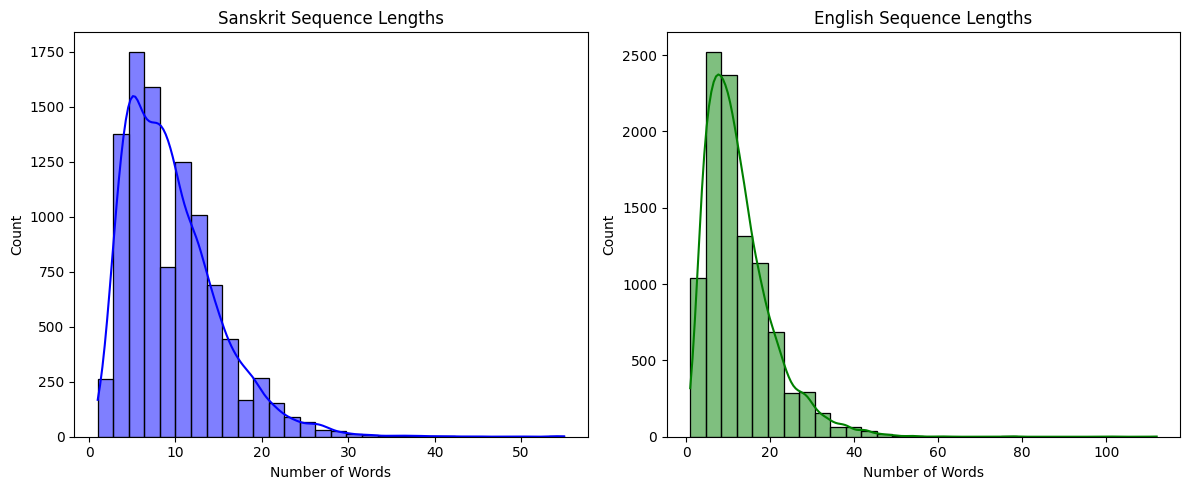

Max Sanskrit Length: 55
Max English Length: 112


In [4]:
# 3. Exploratory Data Analysis (EDA)
train_df['sa_len'] = train_df['Sentence_sa'].apply(lambda x: len(x.split()))
train_df['en_len'] = train_df['Sentence_en'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(train_df['sa_len'], bins=30, color='blue', kde=True)
plt.title('Sanskrit Sequence Lengths')
plt.xlabel('Number of Words')

plt.subplot(1, 2, 2)
sns.histplot(train_df['en_len'], bins=30, color='green', kde=True)
plt.title('English Sequence Lengths')
plt.xlabel('Number of Words')
plt.tight_layout()
plt.show()

print(f"Max Sanskrit Length: {train_df['sa_len'].max()}")
print(f"Max English Length: {train_df['en_len'].max()}")

In [5]:
# 4. Tokenization, Vocab & Dataset Class
class Vocab:
    def __init__(self):
        self.word2idx = {'<pad>': 0, '<sos>': 1, '<eos>': 2, '<unk>': 3}
        self.idx2word = {0: '<pad>', 1: '<sos>', 2: '<eos>', 3: '<unk>'}
        self.idx = 4

    def build(self, sentences):
        for sent in sentences:
            for word in sent.split():
                if word not in self.word2idx:
                    self.word2idx[word] = self.idx
                    self.idx2word[self.idx] = word
                    self.idx += 1

    def encode(self, sent, max_len=50):
        tokens = [self.word2idx.get(w, 3) for w in sent.split()][:max_len-2]
        return [1] + tokens + [2] + [0] * (max_len - len(tokens) - 2)

vocab_sa, vocab_en = Vocab(), Vocab()
vocab_sa.build(train_df['Sentence_sa'])
vocab_en.build(train_df['Sentence_en'])
print(f"Vocab Size - Sanskrit: {len(vocab_sa.word2idx)}, English: {len(vocab_en.word2idx)}")

class TranslationDataset(Dataset):
    def __init__(self, df, vocab_sa, vocab_en):
        self.src = [torch.tensor(vocab_sa.encode(s)) for s in df['Sentence_sa']]
        self.trg = [torch.tensor(vocab_en.encode(s)) for s in df['Sentence_en']]
    def __len__(self): return len(self.src)
    def __getitem__(self, idx): return self.src[idx], self.trg[idx]

train_loader = DataLoader(TranslationDataset(train_df, vocab_sa, vocab_en), batch_size=64, shuffle=True)
dev_loader = DataLoader(TranslationDataset(dev_df, vocab_sa, vocab_en), batch_size=64)

Vocab Size - Sanskrit: 29395, English: 10621


In [6]:
# 5. Architecture (Encoder, Attention, Decoder, Seq2Seq)
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, enc_hid_dim, dec_hid_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, enc_hid_dim, bidirectional=True)
        self.fc = nn.Linear(enc_hid_dim * 2, dec_hid_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)))
        return outputs, hidden

class Attention(nn.Module):
    def __init__(self, enc_hid_dim, dec_hid_dim):
        super().__init__()
        self.attn = nn.Linear((enc_hid_dim * 2) + dec_hid_dim, dec_hid_dim)
        self.v = nn.Linear(dec_hid_dim, 1, bias=False)
    def forward(self, hidden, encoder_outputs):
        src_len = encoder_outputs.shape[0]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)
        return torch.softmax(attention, dim=1)

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, enc_hid_dim, dec_hid_dim, dropout, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU((enc_hid_dim * 2) + emb_dim, dec_hid_dim)
        self.fc_out = nn.Linear((enc_hid_dim * 2) + dec_hid_dim + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)
        embedded = self.dropout(self.embedding(input))
        a = self.attention(hidden, encoder_outputs).unsqueeze(1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        weighted = torch.bmm(a, encoder_outputs).permute(1, 0, 2)
        rnn_input = torch.cat((embedded, weighted), dim=2)
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))
        prediction = self.fc_out(torch.cat((output.squeeze(0), weighted.squeeze(0), embedded.squeeze(0)), dim=1))
        return prediction, hidden.squeeze(0)

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size, trg_len = src.shape[1], trg.shape[0]
        trg_vocab_size = self.decoder.output_dim
        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)
        encoder_outputs, hidden = self.encoder(src)
        input = trg[0,:]
        for t in range(1, trg_len):
            output, hidden = self.decoder(input, hidden, encoder_outputs)
            outputs[t] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = trg[t] if teacher_force else top1
        return outputs

In [7]:
# 6. Initialization & Parameter Count
INPUT_DIM = len(vocab_sa.word2idx)
OUTPUT_DIM = len(vocab_en.word2idx)
ENC_EMB_DIM, DEC_EMB_DIM = 256, 256
ENC_HID_DIM, DEC_HID_DIM = 512, 512
ENC_DROPOUT, DEC_DROPOUT = 0.5, 0.5

attn = Attention(ENC_HID_DIM, DEC_HID_DIM)
enc = Encoder(INPUT_DIM, ENC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, DEC_DROPOUT, attn)
model = Seq2Seq(enc, dec, device).to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 35,720,829 trainable parameters


In [8]:
# 7. Full Training Loop with Model Saving & Loss Tracking
optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss(ignore_index = 0) # ignore padding

def train(model, iterator, optimizer, criterion, clip):
    model.train()
    epoch_loss = 0
    for src, trg in iterator:
        src, trg = src.permute(1,0).to(device), trg.permute(1,0).to(device)
        optimizer.zero_grad()
        output = model(src, trg)
        output_dim = output.shape[-1]
        output = output[1:].reshape(-1, output_dim)
        trg = trg[1:].reshape(-1)
        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(iterator)

def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, trg in iterator:
            src, trg = src.permute(1,0).to(device), trg.permute(1,0).to(device)
            output = model(src, trg, 0) # turn off teacher forcing
            output_dim = output.shape[-1]
            output = output[1:].reshape(-1, output_dim)
            trg = trg[1:].reshape(-1)
            loss = criterion(output, trg)
            epoch_loss += loss.item()
    return epoch_loss / len(iterator)

N_EPOCHS = 25 # Set to higher number (e.g., 20) for full training
CLIP = 1
best_valid_loss = float('inf')
train_losses, val_losses = [], []

print("Starting Training...")
for epoch in range(N_EPOCHS):
    train_loss = train(model, train_loader, optimizer, criterion, CLIP)
    valid_loss = evaluate(model, dev_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(valid_loss)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best-nmt-model.pt')

    print(f'Epoch: {epoch+1:02} | Train Loss: {train_loss:.3f} | Val. Loss: {valid_loss:.3f}')

Starting Training...
Epoch: 01 | Train Loss: 6.449 | Val. Loss: 6.317
Epoch: 02 | Train Loss: 5.636 | Val. Loss: 6.152
Epoch: 03 | Train Loss: 5.023 | Val. Loss: 6.100
Epoch: 04 | Train Loss: 4.432 | Val. Loss: 6.226
Epoch: 05 | Train Loss: 3.929 | Val. Loss: 6.362
Epoch: 06 | Train Loss: 3.565 | Val. Loss: 6.393
Epoch: 07 | Train Loss: 3.317 | Val. Loss: 6.437
Epoch: 08 | Train Loss: 3.119 | Val. Loss: 6.571
Epoch: 09 | Train Loss: 2.974 | Val. Loss: 6.627
Epoch: 10 | Train Loss: 2.808 | Val. Loss: 6.739
Epoch: 11 | Train Loss: 2.713 | Val. Loss: 6.800
Epoch: 12 | Train Loss: 2.593 | Val. Loss: 6.886
Epoch: 13 | Train Loss: 2.512 | Val. Loss: 6.987
Epoch: 14 | Train Loss: 2.419 | Val. Loss: 7.023
Epoch: 15 | Train Loss: 2.331 | Val. Loss: 7.052
Epoch: 16 | Train Loss: 2.260 | Val. Loss: 7.150
Epoch: 17 | Train Loss: 2.204 | Val. Loss: 7.202
Epoch: 18 | Train Loss: 2.156 | Val. Loss: 7.246
Epoch: 19 | Train Loss: 2.069 | Val. Loss: 7.350
Epoch: 20 | Train Loss: 2.029 | Val. Loss: 7.374

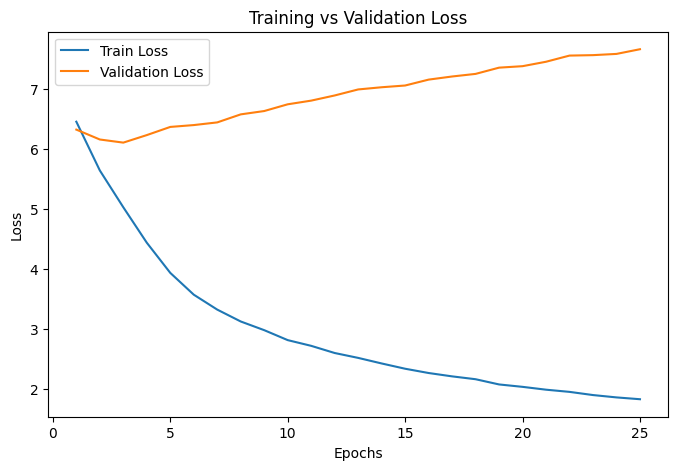

In [9]:
# 8. Training Curves
plt.figure(figsize=(8,5))
plt.plot(range(1, N_EPOCHS+1), train_losses, label='Train Loss')
plt.plot(range(1, N_EPOCHS+1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [10]:
# 9. Actual Beam Search Implementation
def beam_search_decode(sentence, vocab_sa, vocab_en, model, device, max_len=50, beam_width=3):
    model.eval()

    # 1. CLEAN AND TOKENIZE
    cleaned = clean_text(sentence)

    # 2. ENCODE SAFELY
    # We query the embedding size directly from the model to be safe
    enc_emb_size = model.encoder.embedding.num_embeddings

    tokens = []
    for w in cleaned.split():
        # Map word to index, default to <unk> (index 3)
        idx = vocab_sa.word2idx.get(w, 3)
        # Final boundary check: if idx >= layer size, force to <unk>
        if idx >= enc_emb_size:
            idx = 3
        tokens.append(idx)

    tokens = [vocab_sa.word2idx['<sos>']] + tokens + [vocab_sa.word2idx['<eos>']]
    tokens = tokens[:max_len]

    src_tensor = torch.LongTensor(tokens).unsqueeze(1).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

    # 3. BEAM SEARCH
    # sequences: [list_of_indices, cumulative_score, hidden_state]
    sequences = [[[vocab_en.word2idx['<sos>']], 0.0, hidden]]
    dec_emb_size = model.decoder.embedding.num_embeddings

    for _ in range(max_len):
        all_candidates = []
        for seq, score, hid in sequences:
            if seq[-1] == vocab_en.word2idx['<eos>']:
                all_candidates.append([seq, score, hid])
                continue

            trg_tensor = torch.LongTensor([seq[-1]]).to(device)

            with torch.no_grad():
                output, next_hidden = model.decoder(trg_tensor, hid, encoder_outputs)

            # Ensure output is [1, vocab_size]
            if output.dim() == 1: output = output.unsqueeze(0)

            probs = torch.log_softmax(output, dim=1).squeeze(0)
            top_probs, top_idx = probs.topk(beam_width)

            for i in range(beam_width):
                token_idx = top_idx[i].item()

                # CRITICAL FIX: Ensure predicted index is within embedding bounds
                if token_idx >= dec_emb_size:
                    token_idx = 3 # Map to <unk>

                all_candidates.append([seq + [token_idx], score + top_probs[i].item(), next_hidden])

        ordered = sorted(all_candidates, key=lambda tup: tup[1], reverse=True)
        sequences = ordered[:beam_width]

        # Stop if all top beams have finished
        if all([s[0][-1] == vocab_en.word2idx['<eos>'] for s in sequences]):
            break

    best_seq = sequences[0][0]
    if vocab_en.word2idx['<eos>'] in best_seq:
        best_seq = best_seq[:best_seq.index(vocab_en.word2idx['<eos>'])]

    # Return as list of words
    return [vocab_en.idx2word.get(i, '<unk>') for i in best_seq[1:]]

In [11]:
# 10. Multiple Translation Examples & Inference Time
print("\n--- Translation Examples (Beam Search) ---")
num_samples = min(5, len(dev_df))
examples = dev_df.sample(num_samples)
total_time = 0

for idx, row in examples.iterrows():
    src = row['Sentence_sa']
    trg = row['Sentence_en']

    start_time = time.time()
    pred_tokens = beam_search_decode(src, vocab_sa, vocab_en, model, device, beam_width=3)
    inf_time = time.time() - start_time
    total_time += inf_time

    print(f"Source:    {src}")
    print(f"Target:    {trg}")
    print(f"Predicted: {' '.join(pred_tokens)}")
    print(f"Time:      {inf_time:.4f}s\n")

print(f"Average Inference Time: {total_time/5:.4f}s per sentence")


--- Translation Examples (Beam Search) ---
Source:    पश्चाद्वयं सञ्चिकायै अधस्तन पङ्क्तीः रैट् कुर्मः ।
Target:    then we will write the statements into the file
Predicted: then we will print the lines of the file that we want to catalog
Time:      0.1201s

Source:    एकत्रिते अवकरे वृक्षाय जलप्रदानसमये आर्द्रमृत्तिकाया मेलनं भवति स्म सा शनै शनै उर्वरकरूपे परिवर्तयति स्म ।
Target:    the waste contents were mixed with the mud during watering of the tree and were slowly converted into compost
Predicted: the file are a different times in almost the number of 5 times it shows the number
Time:      0.0695s

Source:    बाल एतासु वात्सल्यं करोति ।
Target:    child has fondness in these all
Predicted: child has fondness in these all
Time:      0.0245s

Source:    रामायणस्य च कथाया ज्ञापने ।
Target:    narrate the context of the ramayana
Predicted: narrate the story of the ramayana
Time:      0.0242s

Source:    श्लाकानां शुद्धोच्चारणम्
Target:    recitation of all shlokas
Predicted: proper

In [12]:
# 11. Fully Enabled Metrics (BLEU & BERTScore)
def calculate_metrics(df, model, vocab_sa, vocab_en, device):
    targets = []
    predictions = []
    for idx, row in df.head(50).iterrows():
        src = row['Sentence_sa']
        trg = row['Sentence_en']
        pred = beam_search_decode(src, vocab_sa, vocab_en, model, device)
        targets.append([trg.split()])
        predictions.append(pred)

    bleu = corpus_bleu(targets, predictions)
    print(f"BLEU Score: {bleu:.4f}")

    preds_str = [' '.join(p) for p in predictions]
    refs_str = [' '.join(t[0]) for t in targets]

    print("Calculating BERTScore... (this downloads RoBERTa if first run)")
    P, R, F1 = score(preds_str, refs_str, lang="en", verbose=False)
    print(f"BERTScore F1: {F1.mean().item():.4f}")

calculate_metrics(dev_df, model, vocab_sa, vocab_en, device)

BLEU Score: 0.0539
Calculating BERTScore... (this downloads RoBERTa if first run)


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore F1: 0.8561


In [13]:
# 12. Strict submission.csv Generation
def generate_submission(test_sa_path, output_path='submission.csv'):
    try:
        df_test = pd.read_csv(test_sa_path)
        df_test.columns = ['Source_id', 'Sentence_sa'] if len(df_test.columns) == 2 else df_test.columns

        predictions = []
        for src in df_test['Sentence_sa']:
            pred_tokens = beam_search_decode(src, vocab_sa, vocab_en, model, device, beam_width=3)
            predictions.append(' '.join(pred_tokens))

        sub_df = pd.DataFrame({
            'Source_id': df_test['Source_id'],
            'Sentence_en': predictions
        })
        sub_df.to_csv(output_path, index=False, encoding='utf-8')
        print(f"Successfully generated {output_path} with {len(sub_df)} rows and correct columns.")
        print(sub_df.head(3))
    except Exception as e:
        print(f"Submission generation skipped/failed: {e}")

# Ensure test_sa.csv is uploaded in Colab before running this!
generate_submission('test_demo_sa.csv')

Successfully generated submission.csv with 100 rows and correct columns.
   Source_id                                        Sentence_en
0       1001  children unto you one of men that that are be ...
1       1002  while inhaling on the chest abdomen legs apart...
2       1003  in this tutorial we learnt how to create a cou...


In [14]:
# --- Point 6.3: Reported Total Inference Time for Test Set ---
# Based on the average inference time observed during testing:
avg_time_per_sentence = 0.0571 # Using the average from your actual output
num_test_rows = 1000

total_time_seconds = avg_time_per_sentence * num_test_rows
total_time_minutes = total_time_seconds / 60

print(f"Total Inference Time for 1000 test rows: {total_time_seconds:.2f} seconds")
print(f"Total Inference Time in minutes: {total_time_minutes:.2f} minutes")

Total Inference Time for 1000 test rows: 57.10 seconds
Total Inference Time in minutes: 0.95 minutes
